In [19]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


manual_file = Path("../data/manual_annotation_50.json")
pred_file = Path("../artworks/PROMPT_10f_20260603/clean_artworks_label_prediction.json")

with manual_file.open("r", encoding="utf-8") as f:
    manual_data = json.load(f)

with pred_file.open("r", encoding="utf-8") as f:
    pred_data = json.load(f)


pred_by_path = {}

for item in pred_data:
    pred_by_path[item["file_path"]] = item["predicted_labels"]


rows = []

for item in manual_data:
    file_path = item["file_path"]

    human_labels = item["classification"]
    pred_labels = pred_by_path.get(
        file_path,
        {
            "entities": [],
            "interaction": [],
            "outcome": []
        }
    )

    for group in ["entities", "interaction", "outcome"]:
        human_tags = set(human_labels.get(group, []))
        pred_tags = set(pred_labels.get(group, []))

        all_tags = sorted(human_tags | pred_tags)

        for tag in all_tags:
            rows.append({
                "file_path": file_path,
                "group": group,
                "tag": tag,
                "human_has": tag in human_tags,
                "pred_has": tag in pred_tags,
                "missing": tag in human_tags and tag not in pred_tags,
                "extra": tag not in human_tags and tag in pred_tags,
            })


comparison_long = pd.DataFrame(rows)

summary = (
    comparison_long
    .groupby(["group", "tag"])
    .agg(
        human_count=("human_has", "sum"),
        pred_count=("pred_has", "sum"),
        missing_count=("missing", "sum"),
        extra_count=("extra", "sum"),
    )
    .reset_index()
)

summary["true_positive"] = summary["human_count"] - summary["missing_count"]

summary["precision"] = (
    summary["true_positive"]
    .div(summary["pred_count"])
    .fillna(0)
)

summary["recall"] = (
    summary["true_positive"]
    .div(summary["human_count"])
    .fillna(0)
)

summary = summary.sort_values(["group", "tag"])

summary

,group,tag,human_count,pred_count,missing_count,extra_count,true_positive,precision,recall
0,entities,processed_audio,8,8,1,1,7,0.875000,0.875000
1,entities,processed_image,27,23,4,0,23,1.000000,0.851852
2,entities,processed_text,7,4,3,0,4,1.000000,0.571429
3,entities,randomness,16,20,0,4,16,0.800000,1.000000
4,entities,synthesized_image,24,42,2,20,22,0.523810,0.916667
5,entities,synthesized_sound,2,4,2,4,0,0.000000,0.000000
6,entities,synthesized_text,14,12,4,2,10,0.833333,0.714286
7,interaction,no,10,18,1,9,9,0.500000,0.900000
8,interaction,yes,42,31,12,1,30,0.967742,0.714286
9,outcome,auditory,8,8,1,1,7,0.875000,0.875000


- precision measures how often the labels added by the model are correct (false positives)
- recall measures how often the model finds the labels that should have been added (false negatives)

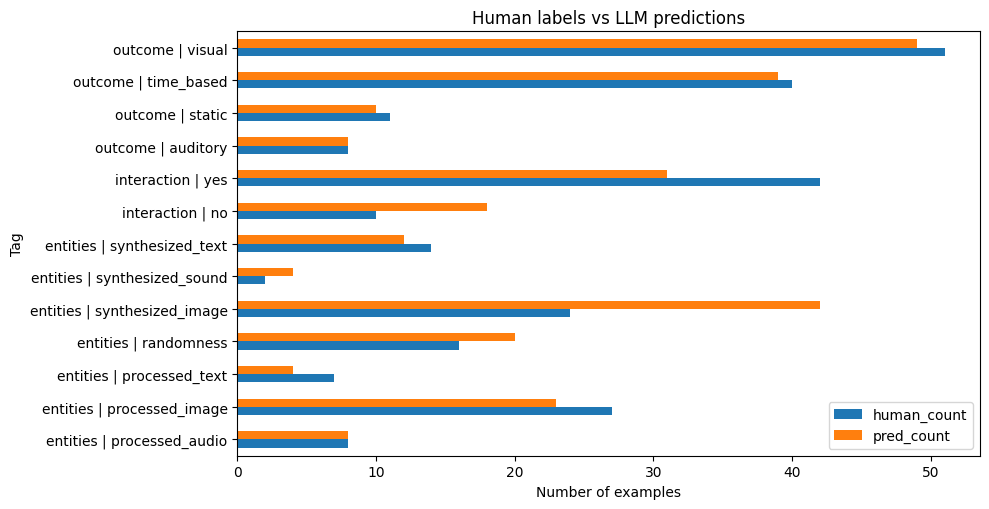

In [3]:
plot_df = summary.set_index("label")[["human_count", "pred_count"]]

ax = plot_df.plot(
    kind="barh",
    figsize=(10, max(5, len(plot_df) * 0.4))
)

ax.set_title("Human labels vs LLM predictions")
ax.set_xlabel("Number of examples")
ax.set_ylabel("Tag")

plt.tight_layout()
plt.show()

In [4]:
def get_paths(comparison_long, group, tag, issue):
    df = comparison_long[
        (comparison_long["group"] == group)
        & (comparison_long["tag"] == tag)
        & (comparison_long[issue])
    ]

    return df["file_path"].tolist()

get_paths(comparison_long, "entities", "synthesized_image", "extra")

['THExCONQUERER/C-37/sketch.js',
 'hbcbh1999/ml4a.github.io/examples/features-simple/sketch.js',
 'legendsaurabh/kangaroo-pt.1/PRO-C38-Template-main/PRO-C38-Template-main/sketch.js',
 'zal96/website/Tutorials/P5JS/p5.js_video/11.7_p5.js_slitscan/sketch.js',
 'roselynmainali/project-11/sketch.js',
 'Lops-Games/Trex/sketch.js',
 'surabibharadhwaj/trex-Umar/sketch.js',
 'cbrusch/dataart2016a/section1/Homework/Reinterpretation HW_Dana/Code example_cellphones/sketch.js',
 'Great-Bennis/kanga-roo/sketch.js',
 'nscoding123/Covid19Game-0321/sketch.js',
 'HaniyaHasan/project-19-/sketch.js',
 'CebollaFrit/proyecto-globos-1/ExplotarGlobos-1-plantilla-main/sketch.js',
 'Anne1916/Trex_V2_C39/sketch.js',
 'harshita2007/catching-game/sketch.js',
 'claudiamiranda/gray-area-immersive-summer-2016/Image_7_image/sketch.js',
 'abhijit-dhar/website/Tutorials/P5JS/p5.js_video/11.5_checkbox_mirror/sketch.js',
 'queensaikia/Online-Courses-Learning/Coursera/Introduction to Computer Programming/Week-1/Assignment

---
# GPT-5.5


For the GPT text, I gave the exact same prompt and the code. Nothing else.


Now comparing with GPT-5.5 thinking:

In [23]:
combined_file = Path("../artworks/PROMPT_10f_20260603/manual_annotations+predictions+gpt_50.json")

with combined_file.open("r", encoding="utf-8") as f:
    data = json.load(f)


rows = []

for item in data:
    human_labels = item.get("classification", {})
    pred_labels = item.get("predicted_labels", {})
    gpt_labels = item.get("gpt_classification", {})

    if isinstance(gpt_labels, str):
        try:
            gpt_labels = json.loads(gpt_labels)
        except:
            continue

    if isinstance(pred_labels, str):
        try:
            pred_labels = json.loads(pred_labels)
        except:
            continue

    if not isinstance(gpt_labels, dict) or not isinstance(pred_labels, dict):
        continue

    comparisons = {
        "gpt_to_human": {
            "reference": human_labels,
            "prediction": gpt_labels,
        },
        "predicted_to_gpt": {
            "reference": gpt_labels,
            "prediction": pred_labels,
        },
    }

    for comparison, labels in comparisons.items():
        reference_labels = labels["reference"]
        prediction_labels = labels["prediction"]

        for group in ["entities", "interaction", "outcome"]:
            reference_tags = set(reference_labels.get(group, []))
            prediction_tags = set(prediction_labels.get(group, []))

            for tag in sorted(reference_tags | prediction_tags):
                rows.append({
                    "file_path": item["file_path"],
                    "comparison": comparison,
                    "group": group,
                    "tag": tag,
                    "reference_has": tag in reference_tags,
                    "prediction_has": tag in prediction_tags,
                    "missing": tag in reference_tags and tag not in prediction_tags,
                    "extra": tag not in reference_tags and tag in prediction_tags,
                })


comparison_long = pd.DataFrame(rows)

summary = (
    comparison_long
    .groupby(["comparison", "group", "tag"])
    .agg(
        reference_count=("reference_has", "sum"),
        pred_count=("prediction_has", "sum"),
        missing_count=("missing", "sum"),
        extra_count=("extra", "sum"),
    )
    .reset_index()
)

summary["true_positive"] = summary["reference_count"] - summary["missing_count"]

summary["precision"] = (
    summary["true_positive"]
    .div(summary["pred_count"])
    .fillna(0)
)

summary["recall"] = (
    summary["true_positive"]
    .div(summary["reference_count"])
    .fillna(0)
)

summary["label"] = summary["group"] + " | " + summary["tag"]


gpt_to_human_table = (
    summary[summary["comparison"] == "gpt_to_human"]
    .drop(columns=["comparison"])
    .rename(columns={
        "reference_count": "human_count",
        "pred_count": "gpt_count"
    })
    .sort_values(["group", "tag"])
)

predicted_to_gpt_table = (
    summary[summary["comparison"] == "predicted_to_gpt"]
    .drop(columns=["comparison"])
    .rename(columns={
        "reference_count": "gpt_count",
        "pred_count": "pred_count"
    })
    .sort_values(["group", "tag"])
)

gpt_to_human_table

,group,tag,human_count,gpt_count,missing_count,extra_count,true_positive,precision,recall,label
0,entities,processed_audio,8,9,0,1,8,0.888889,1.000000,entities | processed_audio
1,entities,processed_image,25,26,0,1,25,0.961538,1.000000,entities | processed_image
2,entities,processed_text,7,7,0,0,7,1.000000,1.000000,entities | processed_text
3,entities,randomness,16,19,0,3,16,0.842105,1.000000,entities | randomness
4,entities,synthesized_image,22,44,0,22,22,0.500000,1.000000,entities | synthesized_image
5,entities,synthesized_sound,2,0,2,0,0,0.000000,0.000000,entities | synthesized_sound
6,entities,synthesized_text,13,9,5,1,8,0.888889,0.615385,entities | synthesized_text
7,interaction,no,10,12,4,6,6,0.500000,0.600000,interaction | no
8,interaction,yes,40,37,7,4,33,0.891892,0.825000,interaction | yes
9,outcome,auditory,8,9,0,1,8,0.888889,1.000000,outcome | auditory


In [25]:
predicted_to_gpt_table

,group,tag,gpt_count,pred_count,missing_count,extra_count,true_positive,precision,recall,label
13,entities,processed_audio,9,8,1,0,8,1.000000,0.888889,entities | processed_audio
14,entities,processed_image,26,23,3,0,23,1.000000,0.884615,entities | processed_image
15,entities,processed_text,7,4,3,0,4,1.000000,0.571429,entities | processed_text
16,entities,randomness,19,20,1,2,18,0.900000,0.947368,entities | randomness
17,entities,synthesized_image,44,42,3,1,41,0.976190,0.931818,entities | synthesized_image
18,entities,synthesized_sound,0,4,0,4,0,0.000000,0.000000,entities | synthesized_sound
19,entities,synthesized_text,9,12,0,3,9,0.750000,1.000000,entities | synthesized_text
20,interaction,no,12,18,0,6,12,0.666667,1.000000,interaction | no
21,interaction,yes,37,31,6,0,31,1.000000,0.837838,interaction | yes
22,outcome,auditory,9,8,1,0,8,1.000000,0.888889,outcome | auditory


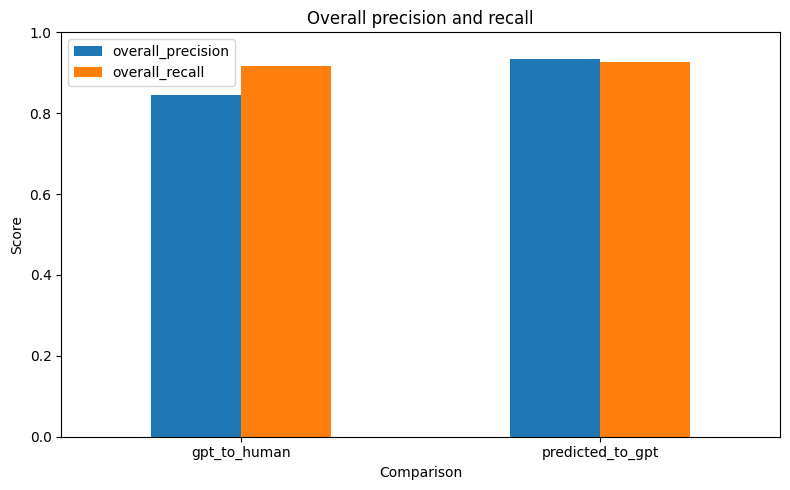

In [28]:
overall_metrics = (
    summary
    .groupby("comparison")
    .agg(
        total_true_positive=("true_positive", "sum"),
        total_reference_count=("reference_count", "sum"),
        total_pred_count=("pred_count", "sum"),
    )
    .reset_index()
)

overall_metrics["overall_precision"] = (
    overall_metrics["total_true_positive"] / overall_metrics["total_pred_count"]
)
overall_metrics["overall_recall"] = (
    overall_metrics["total_true_positive"] / overall_metrics["total_reference_count"]
)

plot_df = overall_metrics.set_index("comparison")[
    ["overall_precision", "overall_recall"]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(8, 5),
    ylim=(0, 1)
)

ax.set_title("Overall precision and recall")
ax.set_ylabel("Score")
ax.set_xlabel("Comparison")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

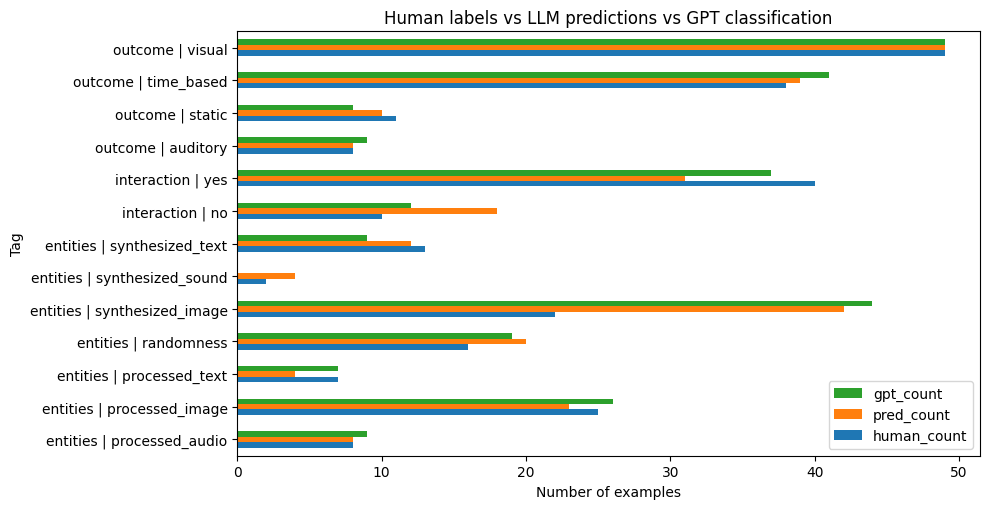

In [30]:
plot_df = (
    gpt_to_human_table[["label", "human_count", "gpt_count"]]
    .merge(
        predicted_to_gpt_table[["label", "pred_count"]],
        on="label",
        how="outer"
    )
    .fillna(0)
    .set_index("label")
)

plot_df = plot_df[["human_count", "pred_count", "gpt_count"]].sort_index()

ax = plot_df.plot(
    kind="barh",
    figsize=(10, max(5, len(plot_df) * 0.4))
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])

ax.set_title("Human labels vs LLM predictions vs GPT classification")
ax.set_xlabel("Number of examples")
ax.set_ylabel("Tag")

plt.tight_layout()
plt.show()